# Phenocycler analysis using SpatialData and SPACEc packages

### Preprocessing, making the phenocycler spatial object

In [1]:
import sopa
import spatialdata as sd
import tifffile as tf
import geopandas
import xarray
import dask.array as da
import numpy as np

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in fu

In [2]:
#SET PATH TO YOUR DIRECTORY CONTAINING PHENOCYCLER IMAGE DIRECTORIES
from pathlib import Path
phenocycler_path = Path(r"D:\Dom\Psoriasis project\4th year data\CellTune\Images\Background Subtract\registered images - Background Subtract 25")


In [ ]:
#generate a multichannel tif for each phenocycler file you have --> only need to run this once for each image

channel_names = ['Vimentin',
 '18s_RNA',
 'AlphaSMA_Vimentin',
 'ATP_Cadherin_CD45',
 'Caveolin',
 'CD3e',
 'CD4',
 'CD8',
 'CD11c',
 'CD20',
 'CD31',
 'CD36',
 'CD44',
 'CD45',
 'CD45R',
 'CD68',
 'CD206',
 'ColA1',
 'dapi',
 'F480',
 'FcYr',
 'FoxP3',
 'Iba1',
 'Ki67',
 'Ly6G',
 'PanCK',
 'S100A9',
 'Ter119'
 ]  # rename as needed

def make_multi_channel(path, channel_names):
    """
    make a multi-channel image from phenocycler data. 
    Requires a directory containing: single channel tifs for each channel, named as such e.g. dapi.tif;
    path = directory to images
    channel_names = list of channel names
    """
    ##
    import tifffile as tf
    import numpy as np
    ##

    image_paths = []
    for channel in channel_names:
        pheno_img_paths = path/(channel + '.tif')
        image_paths.append(pheno_img_paths)

    # Read images
    image_list = [tf.imread(x) for x in image_paths]

    # Stack into multi-channel array: shape (num_channels, y, x)
    multi_channel = np.stack(image_list, axis=0)
    del image_list #RAM saver 

    # Save with channel metadata
    tf.imwrite(
        path/'all_channels.tif',
        multi_channel,
        imagej=True,
        metadata={'Labels': channel_names}
    )


for dir in phenocycler_path.glob("*"):
    if dir.is_dir():
        print(f'converting {dir.name}...')
        try:
            make_multi_channel(dir, channel_names=channel_names)
        except Exception as e:
            print(f'converting {dir.name} failed: {type(e).__name__}: {e}')

converting WT_F...
converting D3_F1...
converting D3_M1...
converting D7_F1...
converting D7_M1...
converting D10_F1...
converting D10_M1...
converting D7_F2...
converting D7_M2...
converting D7_M3...


<tifffile.TiffFile '18s_RNA.tif'> OME series failed to read 'dapi_C0.ome.tif', raised FileNotFoundError(2, 'No such file or directory'). Missing data are zeroed
<tifffile.TiffFile '18s_RNA.tif'> OME series failed to read 3 files
<tifffile.TiffFile 'AlphaSMA_Vimentin.tif'> OME series failed to read 'dapi_C0.ome.tif', raised FileNotFoundError(2, 'No such file or directory'). Missing data are zeroed
<tifffile.TiffFile 'AlphaSMA_Vimentin.tif'> OME series failed to read 3 files


converting WT_M2...


<tifffile.TiffFile 'ATP_Cadherin_CD45.tif'> OME series failed to read 'dapi_C0.ome.tif', raised FileNotFoundError(2, 'No such file or directory'). Missing data are zeroed
<tifffile.TiffFile 'ATP_Cadherin_CD45.tif'> OME series failed to read 3 files
<tifffile.TiffFile 'dapi.tif'> OME series failed to read 'dapi_C1.ome.tif', raised FileNotFoundError(2, 'No such file or directory'). Missing data are zeroed
<tifffile.TiffFile 'dapi.tif'> OME series failed to read 3 files


converting WT_M2 failed: ValueError: all input arrays must have the same shape


In [11]:
#Make a spatialdata object from a phenocycler image
#do this for each image
from spatialdata.models import Labels2DModel
from spatialdata.transformations import Identity

def make_pheno_sd(path):
    """
    make a multi-channel image from phenocycler data. 
    Requires a directory containing: multi_channel.tif file (c, w, h), segmentation_labels.tif
    
    inputs 
    - path to directory containing image and segmentation file

    Returns
    - spatialdata object
    """

    channels_renaming = {}
    pheno_img = sopa.io.phenocycler(path/'all_channels.tif', channels_renaming=None, image_models_kwargs=None)

    # Read and register the segmentation as a Labels2DModel
    seg_raw = tf.imread(path/"xen_all_masks.tif")

    seg_label = Labels2DModel.parse(
        da.from_array(seg_raw),
        dims=["y", "x"],
        transformations={"global": Identity()},
    )

    pheno_img.labels["segmentation_mask"] = seg_label

    # Derive shapes from labels for sopa.aggregate
    cells = sd.to_polygons(pheno_img.labels["segmentation_mask"])
    cells.index = cells.index.astype(str)  # still needed for shapes layer
    pheno_img.shapes["cells"] = cells

    #aggregate 
    sopa.aggregate(pheno_img, 
        aggregate_channels = True,
        shapes_key = 'cells', #whatever shapes object your segmentation_labels are
        expand_radius_ratio = 0.1
        #drop_filtered_cells = True
    )

    return pheno_img

samples = {}

for dir in phenocycler_path.glob("*"):
    if dir.is_dir():
        try:
            samples[dir.name] = make_pheno_sd(dir)
        except Exception as e:
            print(f'making {dir.name} into spatialdata failed: {type(e).__name__}: {e}')

samples

[INFO] (sopa.io.reader.phenocycler) Found channel names ['Vimentin', '18s_RNA', 'AlphaSMA_Vimentin', 'ATP_Cadherin_CD45', 'Caveolin', 'CD3e', 'CD4', 'CD8', 'CD11c', 'CD20', 'CD31', 'CD36', 'CD44', 'CD45', 'CD45R', 'CD68', 'CD206', 'ColA1', 'dapi', 'F480', 'FcYr', 'FoxP3', 'Iba1', 'Ki67', 'Ly6G', 'PanCK', 'S100A9', 'Ter119']
[INFO] (sopa.aggregation.channels) Aggregating channels intensity over 4588 cells with mode='average'


[########################################] | 100% Completed | 10.28 s


[INFO] (sopa.aggregation.aggregation) Filtering 9 cells due to mean channel intensity < 13.93
[INFO] (sopa.io.reader.phenocycler) Found channel names ['Vimentin', '18s_RNA', 'AlphaSMA_Vimentin', 'ATP_Cadherin_CD45', 'Caveolin', 'CD3e', 'CD4', 'CD8', 'CD11c', 'CD20', 'CD31', 'CD36', 'CD44', 'CD45', 'CD45R', 'CD68', 'CD206', 'ColA1', 'dapi', 'F480', 'FcYr', 'FoxP3', 'Iba1', 'Ki67', 'Ly6G', 'PanCK', 'S100A9', 'Ter119']
[INFO] (sopa.aggregation.channels) Aggregating channels intensity over 5467 cells with mode='average'


[########################################] | 100% Completed | 6.54 sms


[INFO] (sopa.aggregation.aggregation) Filtering 1 cells due to mean channel intensity < 19.75
[INFO] (sopa.io.reader.phenocycler) Found channel names ['Vimentin', '18s_RNA', 'AlphaSMA_Vimentin', 'ATP_Cadherin_CD45', 'Caveolin', 'CD3e', 'CD4', 'CD8', 'CD11c', 'CD20', 'CD31', 'CD36', 'CD44', 'CD45', 'CD45R', 'CD68', 'CD206', 'ColA1', 'dapi', 'F480', 'FcYr', 'FoxP3', 'Iba1', 'Ki67', 'Ly6G', 'PanCK', 'S100A9', 'Ter119']
[INFO] (sopa.aggregation.channels) Aggregating channels intensity over 6594 cells with mode='average'


...

[########################################] | 100% Completed | 6.72 sms


[INFO] (sopa.aggregation.aggregation) Filtering 0 cells due to mean channel intensity < 20.80
[INFO] (sopa.io.reader.phenocycler) Found channel names ['Vimentin.tif\nImageDescription: <?xml version="1.0" encoding="UTF-8"?><OME xmlns="http://www.openmicroscopy.org/Schemas/OME/2016-06" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.openmicroscopy.org/Schemas/OME/2016-06 http://www.openmicroscopy.org/Schemas/OME/2016-06/ome.xsd" UUID="urn:uuid:2534f02b-0287-11f1-98ee-94b6093869a8" Creator="tifffile.py 2025.10.16"><Image ID="Image:0" Name="Image0"><Pixels ID="Pixels:0" DimensionOrder="XYCZT" Type="uint16" SizeX="9017" SizeY="941" SizeC="1" SizeZ="1" SizeT="1"><Channel ID="Channel:0:0" SamplesPerPixel="1"><LightPath/></Channel><TiffData IFD="0" PlaneCount="1"/></Pixels></Image></OME>\nSoftware: tifffile.py\n', '18s_RNA.tif\nImageDescription: <?xml version="1.0" encoding="UTF-8"?><!-- Warning: this comment is an OME-XML metadata block, which contains cru

[########################################] | 100% Completed | 4.13 sms


[INFO] (sopa.aggregation.aggregation) Filtering 8 cells due to mean channel intensity < 27.51


{'WT_F': SpatialData object
 ├── Images
 │     └── 'all_channels': DataTree[cyx] (28, 3024, 10056), (28, 1512, 5028), (28, 756, 2514), (28, 378, 1257), (28, 189, 628)
 ├── Labels
 │     └── 'segmentation_mask': DataArray[yx] (3024, 10056)
 ├── Shapes
 │     └── 'cells': GeoDataFrame shape: (4579, 2) (2D shapes)
 └── Tables
       └── 'table': AnnData (4579, 28)
 with coordinate systems:
     ▸ 'global', with elements:
         all_channels (Images), segmentation_mask (Labels), cells (Shapes),
 'D3_F1': SpatialData object
 ├── Images
 │     └── 'all_channels': DataTree[cyx] (28, 1500, 9024), (28, 750, 4512), (28, 375, 2256), (28, 187, 1128), (28, 93, 564)
 ├── Labels
 │     └── 'segmentation_mask': DataArray[yx] (1500, 9024)
 ├── Shapes
 │     └── 'cells': GeoDataFrame shape: (5466, 2) (2D shapes)
 └── Tables
       └── 'table': AnnData (5466, 28)
 with coordinate systems:
     ▸ 'global', with elements:
         all_channels (Images), segmentation_mask (Labels), cells (Shapes),
 'D3_M1

In [12]:
#add compartment shapes to spatialdata object
#Add in compartment segmentation to the spatialdata objects
import geopandas as gp
import numpy as np
from pathlib import Path
from spatialdata.models import ShapesModel

def add_compartment_segmentations(sdata, compartment_segmentation_folder):
    """
    add a collection of tissue segmentations to the an sdata object. Updates the sdata object and the anndata object contained within.
    inputs:
        -sdata = sdata object
        -Compartment_segmentation_folders = path to folder with segmentation.geojson files
    """
    
    compartment_paths = {}
    compartment_segmentation_folder = Path(compartment_segmentation_folder)
    for file in compartment_segmentation_folder.glob("*.geojson"):
        compartment_paths[file.stem] = str(file)

    for compartment, path in compartment_paths.items():
        geojson = gp.read_file(path)
        shape = geojson.geometry.union_all()
        gdf = gp.GeoDataFrame(geometry=[shape])
        sdata.shapes[compartment] = ShapesModel.parse(gdf)

    adata = sdata.tables['table']
    obs = adata.obs
    spatial_coords = adata.obsm['spatial']

    default_shapes = {'cells'}
    compartment_shapes = {k: v for k, v in sdata.shapes.items() if k not in default_shapes}

    cell_points = gp.GeoDataFrame(
        obs,
        geometry=gp.points_from_xy(
            spatial_coords[:, 0],
            spatial_coords[:, 1] 
        ),
        index=obs.index
    )

    compartment_gdf = gp.GeoDataFrame(
        {'compartment': list(compartment_shapes.keys())},
        geometry=[v.geometry.iloc[0] for v in compartment_shapes.values()]
    )

    if 'compartment' in adata.obs.columns:
        adata.obs.drop(columns='compartment', inplace=True)
    joined = gp.sjoin(cell_points, compartment_gdf, how='left', predicate='within')
    # Drop duplicate cells, keeping first match
    joined = joined[~joined.index.duplicated(keep='first')]

    adata.obs['compartment'] = joined['compartment'].fillna('out_of_bounds').values

#dictionary containing condition names and compartment_segmentation folder paths (contains your geojson segmentations)
segs = {}
for dir in phenocycler_path.glob("*"):
    if dir.is_dir():
        segs[dir.name] = Path(dir / "compartment_segmentations")

segs


for condition, sdata in samples.items():
    add_compartment_segmentations(sdata, segs[condition])
    print('added shapes and labelled cells. Unique compartments below')
    print(sdata.tables['table'].obs['compartment'].unique())




added shapes and labelled cells. Unique compartments below
['out_of_bounds' 'Cartilage' 'Dermis' 'Hair_Follicles' 'Epidermis']
added shapes and labelled cells. Unique compartments below
['out_of_bounds' 'Cartilage' 'Dermis' 'Hair_Follicles' 'Epidermis']
added shapes and labelled cells. Unique compartments below
['Epidermis' 'Hair_Follicles' 'Dermis' 'out_of_bounds' 'Cartilage']
added shapes and labelled cells. Unique compartments below
['out_of_bounds' 'Cartilage' 'Dermis' 'Epidermis' 'Hair_Follicles']
added shapes and labelled cells. Unique compartments below
['Epidermis' 'Dermis' 'Hair_Follicles' 'Cartilage' 'out_of_bounds']
added shapes and labelled cells. Unique compartments below
['Epidermis' 'Dermis' 'Cartilage' 'Hair_Follicles' 'out_of_bounds']
added shapes and labelled cells. Unique compartments below
['out_of_bounds' 'Cartilage' 'Dermis' 'Epidermis' 'Hair_Follicles']
added shapes and labelled cells. Unique compartments below
['out_of_bounds' 'Cartilage' 'Dermis' 'Hair_Follicle

In [14]:
#Give each anndata table a column that specifies the sample of origin
for name, sdata in samples.items():
    sdata.tables['table'].obs['sample'] = name

#check it's worked
samples['D10_F1'].tables['table']

AnnData object with n_obs × n_vars = 6880 × 28
    obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'spatial'

In [18]:
import anndata as ad

def save_zarr_and_adata(sdata, zarr_path, h5ad_path):
    """
    Save the spatialdata and associated anndata tables as separate files (spatialdata will contain the anndata as well)
    """

    #save the spatialdata object
    sdata.write(zarr_path)

    #save the anndata table
    adata = sdata.tables['table']
    adata.write_h5ad(h5ad_path)

for sample, sdata in samples.items():
    zarr_path = phenocycler_path / sample / (sample + 'sdata.zarr')
    h5ad_path = phenocycler_path / sample / (sample + 'adata.h5ad')
    save_zarr_and_adata(sdata, zarr_path, h5ad_path)

# SPACEc Analysis 

#### Tan, Y., Kempchen, T.N., Becker, M. et al. SPACEc: a streamlined, interactive Python workflow for multiplexed image processing and analysis. Nat Commun 16, 10652 (2025). https://doi.org/10.1038/s41467-025-65658-3

## Filtering cells and normalising channel intensities

In [43]:
#SET PATH TO YOUR DIRECTORY CONTAINING PHENOCYCLER IMAGE DIRECTORIES
from pathlib import Path
phenocycler_path = Path(r"D:\Dom\Psoriasis project\4th year data\CellTune\Images\Background Subtract\registered images - Background Subtract 25")

In [44]:
#load in your data
import anndata as ad

samples = {}

for dir in phenocycler_path.glob("*"):
    if dir.is_dir():
        sample = dir.name
        h5ad_path = phenocycler_path / sample / (sample + 'adata.h5ad')
        samples[dir.name] = ad.read_h5ad(h5ad_path)

samples

{'WT_F': AnnData object with n_obs × n_vars = 4579 × 28
     obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample'
     uns: 'sopa_attrs', 'spatialdata_attrs'
     obsm: 'spatial',
 'D3_F1': AnnData object with n_obs × n_vars = 5466 × 28
     obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample'
     uns: 'sopa_attrs', 'spatialdata_attrs'
     obsm: 'spatial',
 'D3_M1': AnnData object with n_obs × n_vars = 6594 × 28
     obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample'
     uns: 'sopa_attrs', 'spatialdata_attrs'
     obsm: 'spatial',
 'D7_F1': AnnData object with n_obs × n_vars = 8752 × 28
     obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample'
     uns: 'sopa_attrs', 'spatialdata_attrs'
     obsm: 'spatial',
 'D7_M1': AnnData object with n_obs × n_vars = 12067 × 28
     obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample'
     uns: 'sopa_attrs', 'spatialdata_attrs'
     obsm: 'spatial',
 'D10_F1': AnnData object

In [45]:
#add channel intensities and x,y coords to your anndata.obs table, for ease of access
for name, adata in samples.items():
    adata.obs = adata.obs.join(adata.to_df())
    adata.obs[['x', 'y']] = adata.obsm['spatial']

samples['WT_F'].obs

,region,slide,cell_id,area,compartment,sample,Vimentin,18s_RNA,AlphaSMA_Vimentin,ATP_Cadherin_CD45,...,FcYr,FoxP3,Iba1,Ki67,Ly6G,PanCK,S100A9,Ter119,x,y
aaaaaaaa-1,cells,all_channels,aaaaaaaa-1,326.5,out_of_bounds,WT_F,2.282828,9.161616,10.212121,472.214646,...,3.010101,12.207071,2.171717,4.573232,22.901515,393.871212,2.214646,0.631313,1591.323762,265.435299
aaaaaaab-1,cells,all_channels,aaaaaaab-1,219.5,out_of_bounds,WT_F,4.100000,11.814286,9.339286,239.250000,...,4.953571,15.982143,3.550000,5.496429,25.600000,350.382143,2.735714,1.767857,1673.479119,266.409643
aaaaaaac-1,cells,all_channels,aaaaaaac-1,192.5,out_of_bounds,WT_F,3.698795,22.176707,9.365462,206.991968,...,7.168675,26.056225,1.931727,2.763052,19.895582,157.000000,2.012048,3.903614,1662.045887,273.428139
aaaaaaad-1,cells,all_channels,aaaaaaad-1,205.5,out_of_bounds,WT_F,1.959707,10.670330,11.289377,450.296703,...,3.252747,13.509158,1.725275,4.483516,29.600733,608.747253,2.501832,1.091575,1500.917478,271.104015
aaaaaaae-1,cells,all_channels,aaaaaaae-1,473.5,out_of_bounds,WT_F,1.681655,12.525180,20.070144,470.242806,...,5.535971,19.181655,1.699640,4.073741,23.901079,88.496403,2.250000,1.343525,1541.809574,276.184970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
aaaabbno-1,cells,all_channels,aaaabbno-1,175.5,Epidermis,WT_F,1.468750,6.875000,10.316964,235.482143,...,3.334821,7.727679,2.133929,2.540179,27.665179,2.678571,1.642857,0.504464,7250.323362,2022.038462
aaaabbnp-1,cells,all_channels,aaaabbnp-1,138.5,Epidermis,WT_F,0.821053,5.100000,11.515789,310.721053,...,2.442105,6.110526,2.678947,1.300000,17.436842,0.800000,1.310526,0.563158,7272.510529,2019.946751
aaaabboa-1,cells,all_channels,aaaabboa-1,140.5,Epidermis,WT_F,2.622951,3.765027,11.016393,232.956284,...,4.032787,9.338798,2.825137,2.448087,28.617486,3.459016,1.568306,1.366120,7236.695136,2022.730724
aaaabbob-1,cells,all_channels,aaaabbob-1,313.5,Epidermis,WT_F,0.766234,1.888312,3.067532,58.633766,...,2.592208,7.584416,2.010390,0.768831,20.735065,31.306494,2.038961,0.623377,7276.753190,2029.013158


In [42]:
#column clearing up, specific to my sample
# table = samples['WT_M2']

# table.obs.columns = [
#     col.split(".")[0] if col not in ["region", "slide", "cell_id", "area", "compartment", "x", "y", "sample"]
#     else col
#     for col in table.obs.columns
# ]
samples['WT_M2'].write_h5ad(r"D:\Dom\Psoriasis project\4th year data\CellTune\Images\Background Subtract\registered images - Background Subtract 25\WT_M2\WT_M2adata.h5ad")

In [46]:
#filter cells according to cell area, dapi intensity

import numpy as np
from collections import defaultdict


def filter_cells(adata):
    #filter cells based on multiple metrics: size, low gene

    total_original_cells = len(adata) 
    total_original_cells_by_compartment = adata.obs['compartment'].value_counts().to_dict()

    #size based
    percentile_threshold = 1 #change this to filter out more or less cells
    size_threshold = np.percentile(adata.obs['area'], percentile_threshold) 

    size_mask = adata.obs['area'] > size_threshold 
    num_removed_size = (~size_mask).sum() #no. cells removed

    adata = adata[size_mask].copy()

    print(f'Removed {num_removed_size/total_original_cells *100:.2f}% of cells based on cell area requirements')


    #dapi based
    dapi_percentile_threshold = 1 #change this to filter out more or less cells
    dapi_threshold = np.percentile(adata.obs['dapi'], dapi_percentile_threshold) 

    size_mask = adata.obs['dapi'] > dapi_threshold 
    num_removed_dapi = (~size_mask).sum() #no. cells removed

    adata = adata[size_mask].copy()

    print(f'Removed {num_removed_dapi/total_original_cells *100:.2f}% of cells based on low dapi intensity')

    total_final_cells = len(adata)
    print(f'Removed {(1-total_final_cells/total_original_cells) *100:.2f}')
   
    # #calculate % of cells removed by compartment
    # total_final_cells_by_compartment = adata.obs['compartment'].value_counts().to_dict()
    
    # original_by_type = defaultdict(int)
    # final_by_type = defaultdict(int)

    # for compartment, count in total_original_cells_by_compartment.items():
    #     comp_type = '_'.join(compartment.split('_')[:-1])
    #     original_by_type[comp_type] += count

    # for compartment, count in total_final_cells_by_compartment.items():
    #     comp_type = '_'.join(compartment.split('_')[:-1])
    #     final_by_type[comp_type] += count

    # for comp_type in sorted(original_by_type.keys()):
    #     original = original_by_type[comp_type]
    #     final = final_by_type.get(comp_type, 0)
    #     pct_removed = (1-final/original) *100
    #     pct_total = ((original-final)/total_original_cells)*100
    #     print(f'{comp_type}: {pct_removed:.2f}% cells removed, or {pct_total:.2f} of total OG cells')


    return adata

for condition, adata in samples.items():
    print(f'{"="*30}QC for {condition}{"="*30}')
    samples[condition] = filter_cells(adata)
    print(samples[condition])
    print("="*80)

==============================QC for WT_F==============================
Removed 1.05% of cells based on cell area requirements
Removed 1.00% of cells based on low dapi intensity
Removed 2.05
AnnData object with n_obs × n_vars = 4485 × 28
    obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample', 'Vimentin', '18s_RNA', 'AlphaSMA_Vimentin', 'ATP_Cadherin_CD45', 'Caveolin', 'CD3e', 'CD4', 'CD8', 'CD11c', 'CD20', 'CD31', 'CD36', 'CD44', 'CD45', 'CD45R', 'CD68', 'CD206', 'ColA1', 'dapi', 'F480', 'FcYr', 'FoxP3', 'Iba1', 'Ki67', 'Ly6G', 'PanCK', 'S100A9', 'Ter119', 'x', 'y'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'spatial'
==============================QC for D3_F1==============================
Removed 1.01% of cells based on cell area requirements
Removed 1.01% of cells based on low dapi intensity
Removed 2.01
AnnData object with n_obs × n_vars = 5356 × 28
    obs: 'region', 'slide', 'cell_id', 'area', 'compartment', 'sample', 'Vimentin', '18s_RNA', 'AlphaSMA_Vimen

In [47]:
#SPACEc (annoyingly) requires csvs not anndata objects for the normalisation steps, so this is just to save and convert.
import pandas as pd

for sample, adata in samples.items():
    save_path = phenocycler_path / sample / 'intensities.csv'
    adata.obs.to_csv(save_path)

In [30]:
marker_columns = [
    'Vimentin', '18s_RNA', 'AlphaSMA_Vimentin', 'ATP_Cadherin_CD45',
       'Caveolin', 'CD3e', 'CD4', 'CD8', 'CD11c', 'CD20', 'CD31', 'CD36',
       'CD44', 'CD45', 'CD45R', 'CD68', 'CD206', 'ColA1', 'dapi', 'F480',
       'FcYr', 'FoxP3', 'Iba1', 'Ki67', 'Ly6G', 'PanCK', 'S100A9', 'Ter119' # etc — edit as needed
]

samples = [x.name for x in Path(phenocycler_path).glob("*") if x.is_dir()]

for sample in samples:
    csv_path = Path(phenocycler_path) / sample / 'intensities.csv'
    df = pd.read_csv(csv_path, index_col=0)
    
    # Remove any Unnamed columns
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    
    # Get remaining columns that aren't markers, preserving their order
    meta_columns = [col for col in df.columns if col not in marker_columns]
    
    df = df[marker_columns + meta_columns]
    df.to_csv(csv_path)

In [1]:
#Read and concatenate the csv files 

#make sure you have spacec installed
import spacec as sp

#SET PATH TO YOUR DIRECTORY CONTAINING PHENOCYCLER IMAGE DIRECTORIES
phenocycler_path = r"D:\Dom\Psoriasis project\4th year data\CellTune\Images\Background Subtract\registered images - Background Subtract 25"

df_seg = sp.pp.read_segdf(
    segfile_list = [ # list of segmented files, read in explicitly to match region list
        phenocycler_path + '/WT_F' + '/intensities.csv',
        phenocycler_path + '/D3_F1' + '/intensities.csv',
        phenocycler_path + '/D7_F1' + '/intensities.csv',
        phenocycler_path + '/D7_F2' + '/intensities.csv',
        phenocycler_path + '/D10_F1' + '/intensities.csv',
        phenocycler_path + '/WT_M2' + '/intensities.csv',
        phenocycler_path + '/D3_M1' + '/intensities.csv',
        phenocycler_path + '/D7_M1' + '/intensities.csv',
        phenocycler_path + '/D7_M2' + '/intensities.csv',
        phenocycler_path + '/D7_M3' + '/intensities.csv',
        phenocycler_path + '/D10_M1' + '/intensities.csv',
    ],
    seg_method = 'cellpose',
    region_list =["WT_F", "D3_F1", 'D7_F1', 'D7_F2', 'D10_F1',
                  'WT_M2', 'D3_M1', 'D7_M1', 'D7_M2', 'D7_M3', 'D10_M1'],
    meta_list = ["WT_F", "D3_F1", 'D7_F1', 'D7_F2', 'D10_F1',
                  'WT_M2', 'D3_M1', 'D7_M1', 'D7_M2', 'D7_M3', 'D10_M1']
)

In [2]:
df_filt = df_seg
df_filt.columns

Index(['Vimentin', '18s_RNA', 'AlphaSMA_Vimentin', 'ATP_Cadherin_CD45',
       'Caveolin', 'CD3e', 'CD4', 'CD8', 'CD11c', 'CD20', 'CD31', 'CD36',
       'CD44', 'CD45', 'CD45R', 'CD68', 'CD206', 'ColA1', 'dapi', 'F480',
       'FcYr', 'FoxP3', 'Iba1', 'Ki67', 'Ly6G', 'PanCK', 'S100A9', 'Ter119',
       'region', 'slide', 'cell_id', 'area', 'compartment', 'sample', 'x', 'y',
       'region_num', 'unique_region', 'condition'],
      dtype='object')

In [4]:
# This is to normalize the data per region/tif
import pandas as pd

dfz = pd.DataFrame()

for region in df_filt.unique_region.unique():
    df_reg = df_filt[df_filt.unique_region == region]
    df_reg_norm = sp.pp.format(
        data=df_reg, 
        list_out= [], # list of features to remove
        list_keep = ["cell_id", "dapi",'x','y', 'area', 'region_num',"unique_region", 'condition', 'slide', 'sample', 'region', 'compartment'], # list of meta information that you would like to keep but don't want to normalize
        method = "double_zscore") # choose from "zscore", "double_zscore", "MinMax", "ArcSin"
    dfz = pd.concat([dfz,df_reg_norm], axis = 0)

dfz.shape

(83879, 39)

### Removing Noisy cells post normalisation

In [5]:
dfz.columns

Index(['Vimentin', '18s_RNA', 'AlphaSMA_Vimentin', 'ATP_Cadherin_CD45',
       'Caveolin', 'CD3e', 'CD4', 'CD8', 'CD11c', 'CD20', 'CD31', 'CD36',
       'CD44', 'CD45', 'CD45R', 'CD68', 'CD206', 'ColA1', 'F480', 'FcYr',
       'FoxP3', 'Iba1', 'Ki67', 'Ly6G', 'PanCK', 'S100A9', 'Ter119', 'cell_id',
       'dapi', 'x', 'y', 'area', 'region_num', 'unique_region', 'condition',
       'slide', 'sample', 'region', 'compartment'],
      dtype='object')

In [6]:
for x in dfz.columns:
    print(x)

Vimentin
18s_RNA
AlphaSMA_Vimentin
ATP_Cadherin_CD45
Caveolin
CD3e
CD4
CD8
CD11c
CD20
CD31
CD36
CD44
CD45
CD45R
CD68
CD206
ColA1
F480
FcYr
FoxP3
Iba1
Ki67
Ly6G
PanCK
S100A9
Ter119
cell_id
dapi
x
y
area
region_num
unique_region
condition
slide
sample
region
compartment


In [7]:
# get the column index for the last marker 
col_num_last_marker = dfz.columns.get_loc('Ter119')
print(col_num_last_marker)

26


WT_F
D3_F1
D7_F1
D7_F2
D10_F1
WT_M2
D3_M1
D7_M1
D7_M2
D7_M3
D10_M1


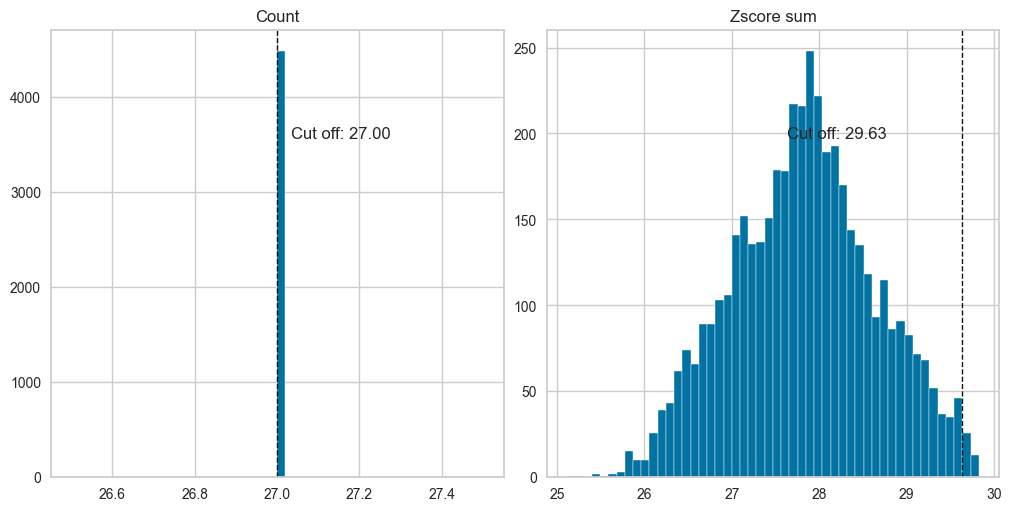

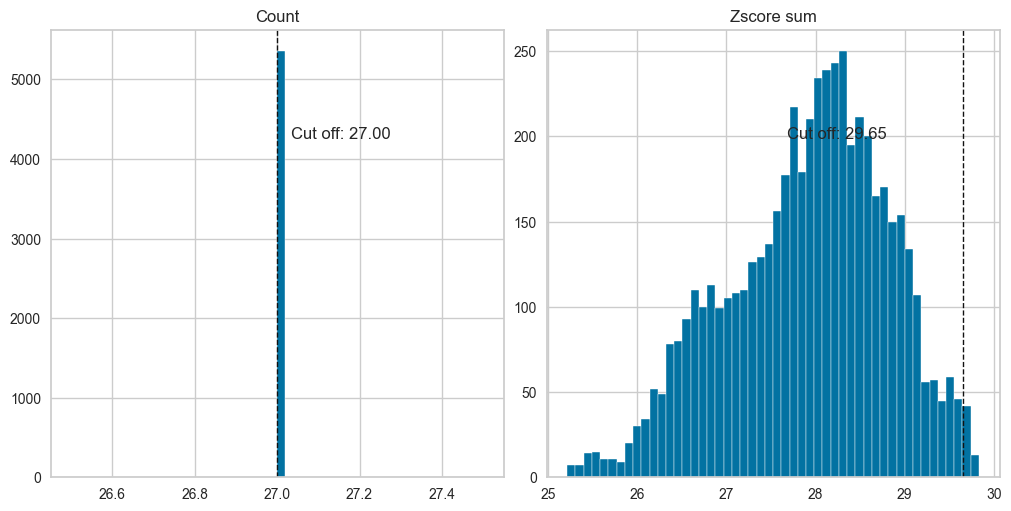

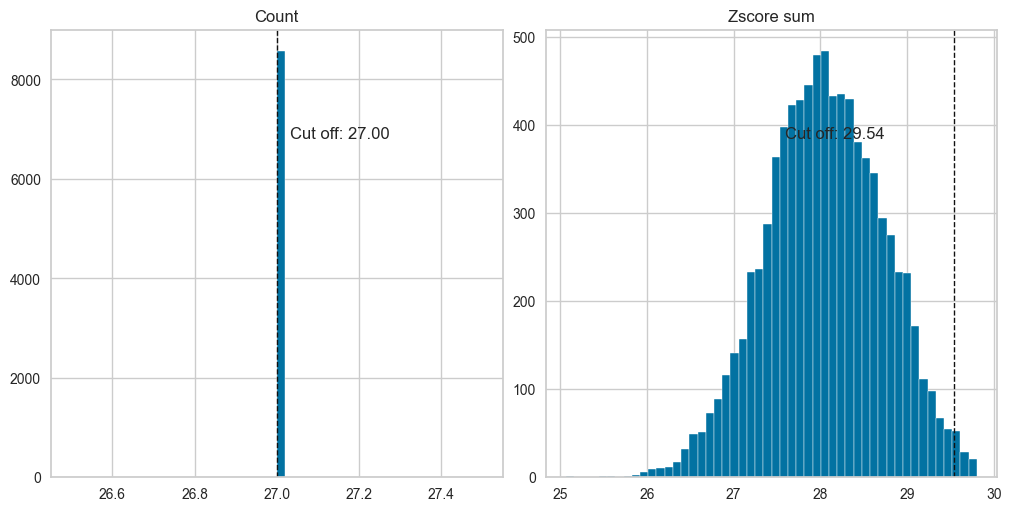

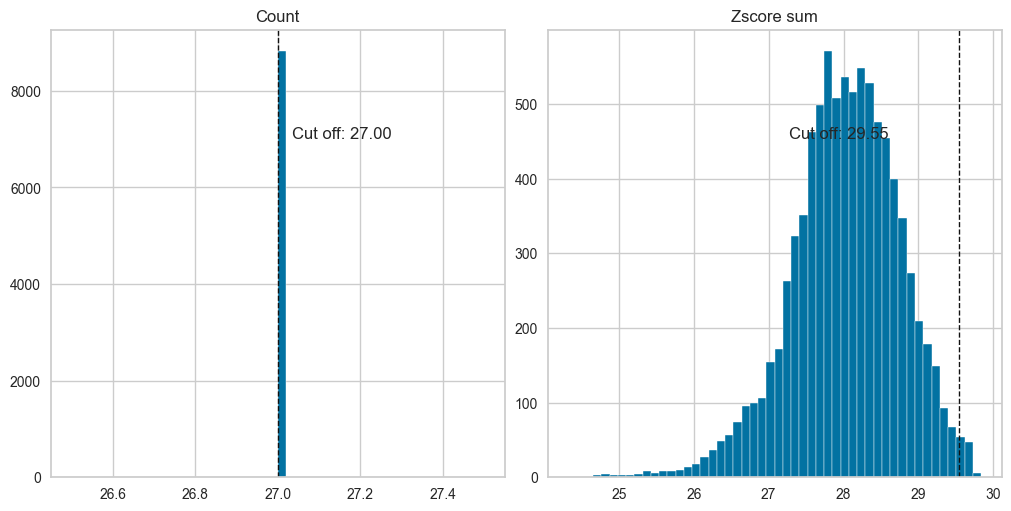

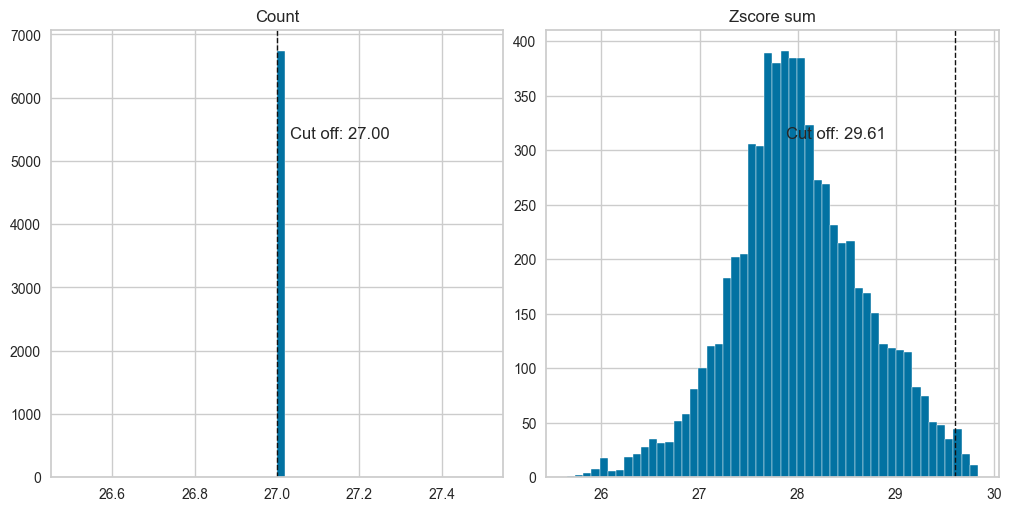

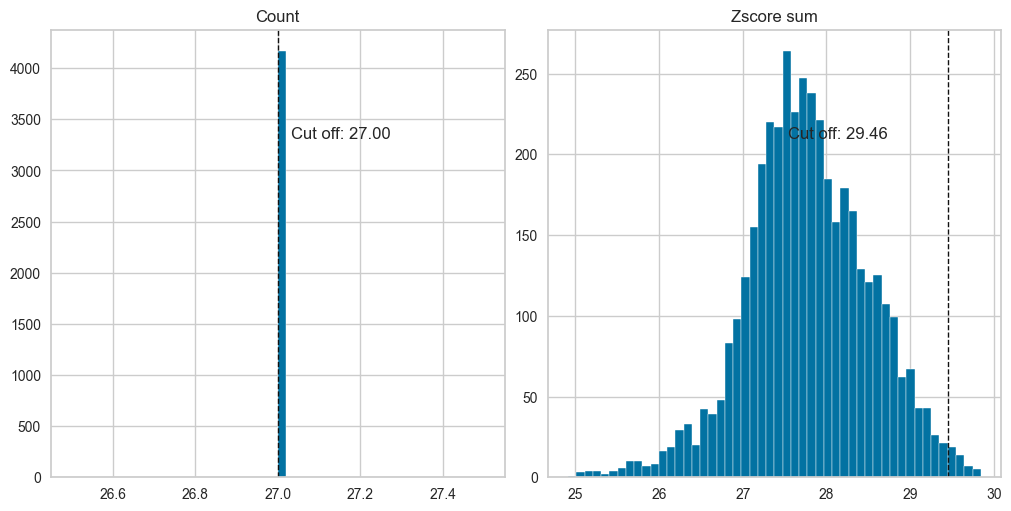

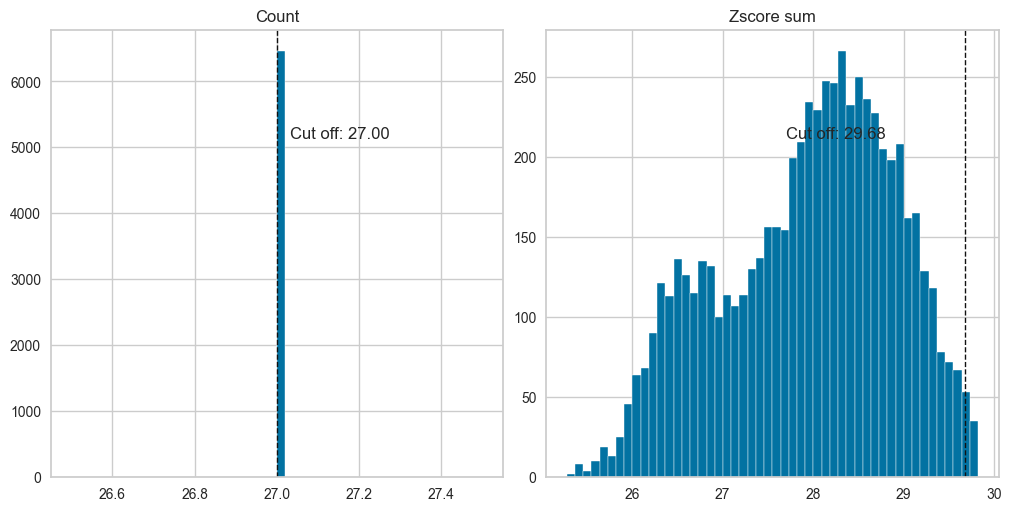

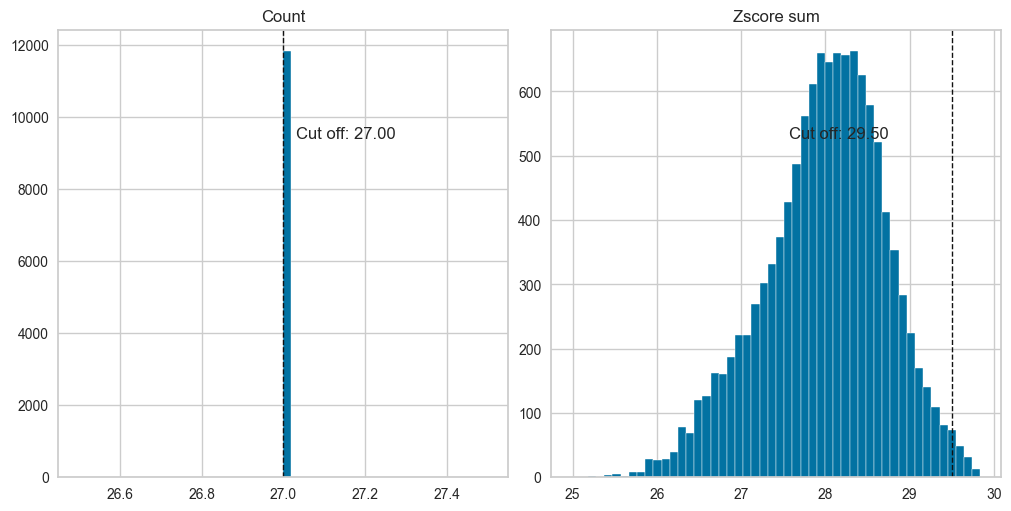

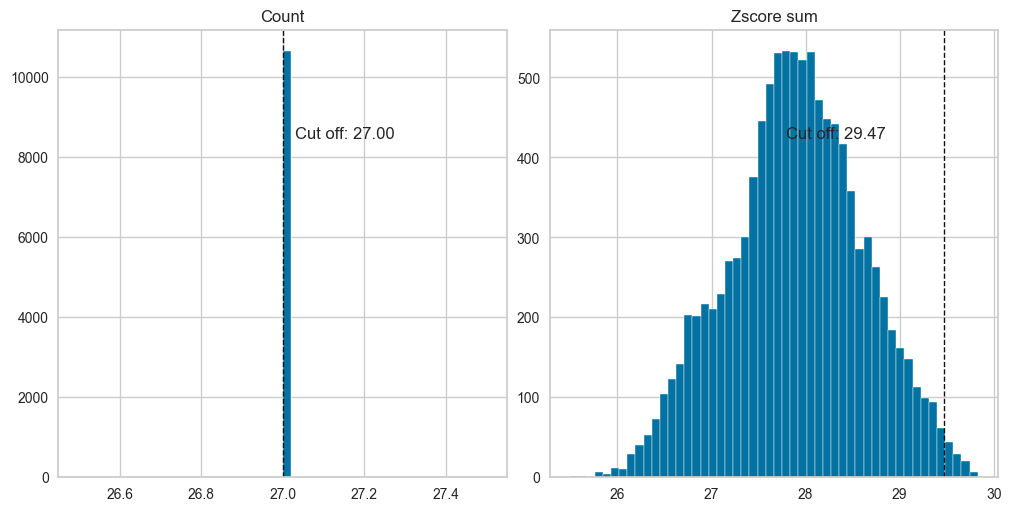

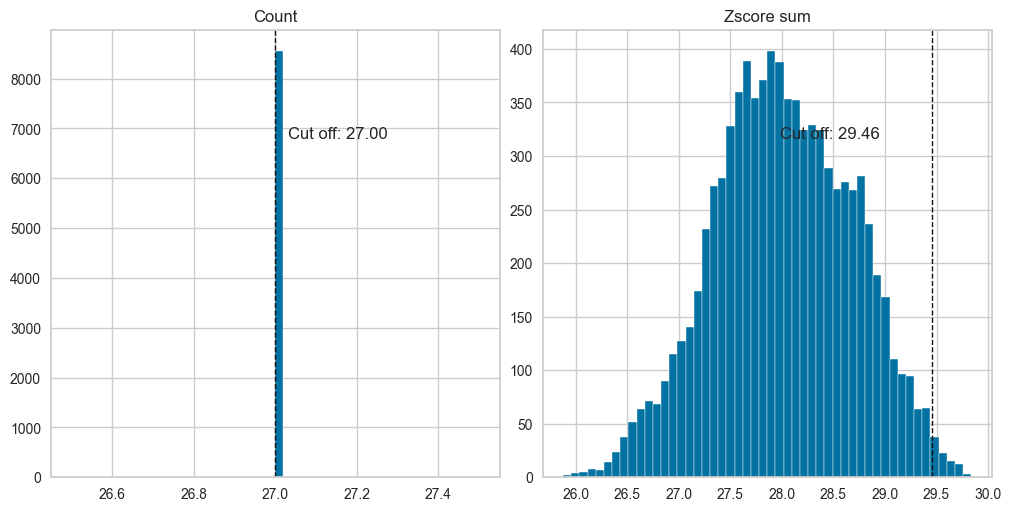

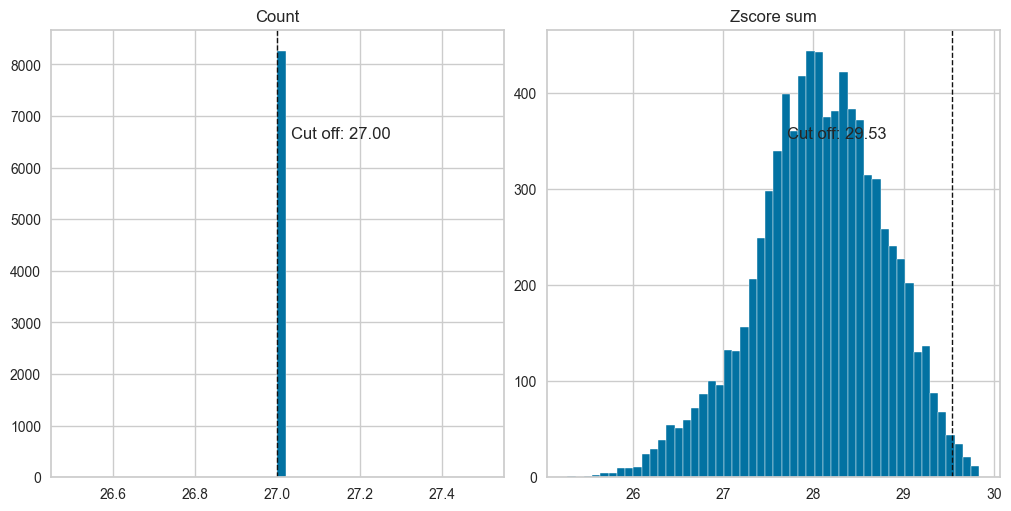

In [8]:
import warnings

for region in dfz.unique_region.unique():
    print(region)
    df_reg = dfz[dfz.unique_region == region]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sp.pl.zcount_thres(dfz = df_reg, 
                    col_num = col_num_last_marker,
                    cut_off=0.01,
                    count_bin=50)

In [9]:
# This is to remove top 1 % of all cells that are highly expressive for all antibodies
df_nn = pd.DataFrame()
cutoff_list = [[27, 29.63], [27, 29.65],[27, 29.54], [27, 29.55], [27, 29.61], [27, 29.46], [27, 29.68], [27,29.5], [27, 29.47], [27, 29.46], [27, 29.53]]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(len(dfz.unique_region.unique())):
        df_reg = dfz[dfz.unique_region == dfz.unique_region.unique()[i]]
        df_reg_nn, cc = sp.pp.remove_noise(
            df=df_reg, 
            col_num=col_num_last_marker,
            z_count_thres=cutoff_list[i][0],
            z_sum_thres=cutoff_list[i][1]
        )
        print(df_reg_nn.shape)
        df_nn = pd.concat([df_nn, df_reg_nn], axis=0)

df_nn.shape

1.0% cells are removed.
(4440, 39)
1.0% cells are removed.
(5302, 39)
1.0999999999999999% cells are removed.
(8481, 39)
1.0% cells are removed.
(8737, 39)
1.0% cells are removed.
(6672, 39)
1.0% cells are removed.
(4126, 39)
1.0% cells are removed.
(6396, 39)
1.0% cells are removed.
(11700, 39)
1.0% cells are removed.
(10531, 39)
1.0% cells are removed.
(8466, 39)
1.0% cells are removed.
(8178, 39)


(83029, 39)

In [10]:
for x in df_nn.columns:
    print(x)

Vimentin
18s_RNA
AlphaSMA_Vimentin
ATP_Cadherin_CD45
Caveolin
CD3e
CD4
CD8
CD11c
CD20
CD31
CD36
CD44
CD45
CD45R
CD68
CD206
ColA1
F480
FcYr
FoxP3
Iba1
Ki67
Ly6G
PanCK
S100A9
Ter119
cell_id
dapi
x
y
area
region_num
unique_region
condition
slide
sample
region
compartment


In [ ]:
#Annoyingly you now have to convert it back to an anndata object, hoorayy! #not sure I've got this bit correct. 

# make an anndata to be compatible with the downstream clustering step
adata = sp.hf.make_anndata(
    df_nn = df_nn,
    col_sum = col_num_last_marker, # this is the column index that has the last protein feature # the rest will go into obs
    nonFuncAb_list = [] # Remove the antibodies that are not working from the clustering step
)
# adata.obs = adata.obs.reset_index(drop=True).join(adata.to_df().reset_index(drop=True))
# adata.obs.index = adata.obs.index.astype(str)  # fix integer index warning
# adata.obs_names_make_unique()                   # fix duplicate obs names warning
# adata

adata.write_h5ad(Path(phenocycler_path)/"processed_adata.h5ad")

# Clustering - with SPACEc

In [21]:
# import spacec first
import spacec as sp

#import standard packages
import os
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# silencing warnings
import warnings
warnings.filterwarnings('ignore')

plt.rc('axes', grid=False)  # remove gridlines
sc.settings.set_figure_params(dpi=80, facecolor='white') # set dpi and background color for scanpy figures

In [32]:
#load your processed data
#SET PATH TO YOUR DIRECTORY CONTAINING PHENOCYCLER IMAGE DIRECTORIES
from pathlib import Path
phenocycler_path = Path(r"D:\Dom\Psoriasis project\4th year data\CellTune\Images\Background Subtract\registered images - Background Subtract 25")

adata = sc.read(phenocycler_path / 'processed_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 83029 × 27
    obs: 'cell_id', 'dapi', 'x', 'y', 'area', 'region_num', 'unique_region', 'condition', 'slide', 'sample', 'region', 'compartment'

In [33]:
import pandas as pd

clustering_random_seed = 0

marker_list = adata.to_df().columns.tolist() #gets the marker names and makes them into a list
#then just keep the ones you want
remove_markers = ['18s_RNA',
 'ATP_Cadherin_CD45',
 'dapi',
 'Ly6G',
 'CD11c',
 'CD4',
 'CD8',
 'CD3e',
 'CD20',
 'CD68']

marker_list = [x for x in marker_list if x not in remove_markers]
marker_list

['Vimentin',
 'AlphaSMA_Vimentin',
 'Caveolin',
 'CD31',
 'CD36',
 'CD44',
 'CD45',
 'CD45R',
 'CD206',
 'ColA1',
 'F480',
 'FcYr',
 'FoxP3',
 'Iba1',
 'Ki67',
 'PanCK',
 'S100A9',
 'Ter119']

In [36]:
# clustering 

#remove out_of_bounds_cells
adata = adata[adata.obs['compartment'] != 'out_of_bounds']

adata = sp.tl.clustering( #this is a wrapper for scanpy functions, so you could use these instead, you'll just have to jig the adata object aorund a bit
    adata, 
    clustering='leiden', # can choose between leiden and louvian
    n_neighbors=15, # number of neighbors for the knn graph
    resolution = 0.25, #clustering resolution (higher resolution gives more clusters)
    reclustering = False, # if true, no computing the neighbors
    marker_list = marker_list, #if it is None, all variable names are used for clustering
    seed=clustering_random_seed, # random seed for clustering - reproducibility
)

Computing neighbors and UMAP
- neighbors
- UMAP
Clustering
Leiden clustering


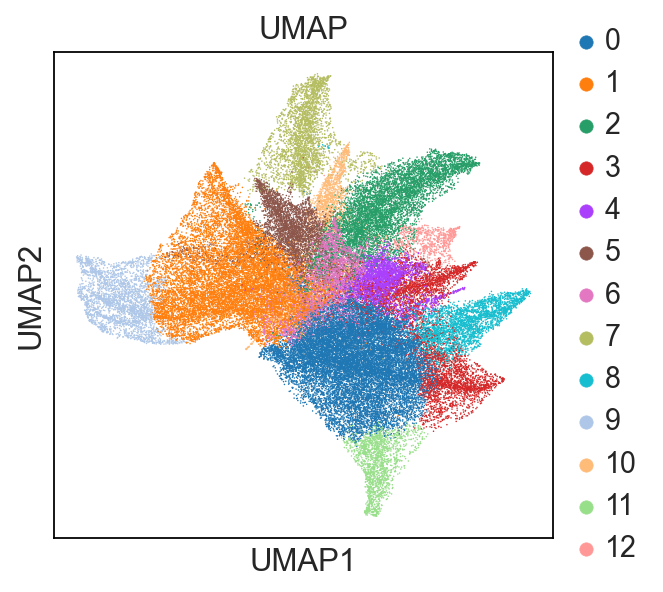

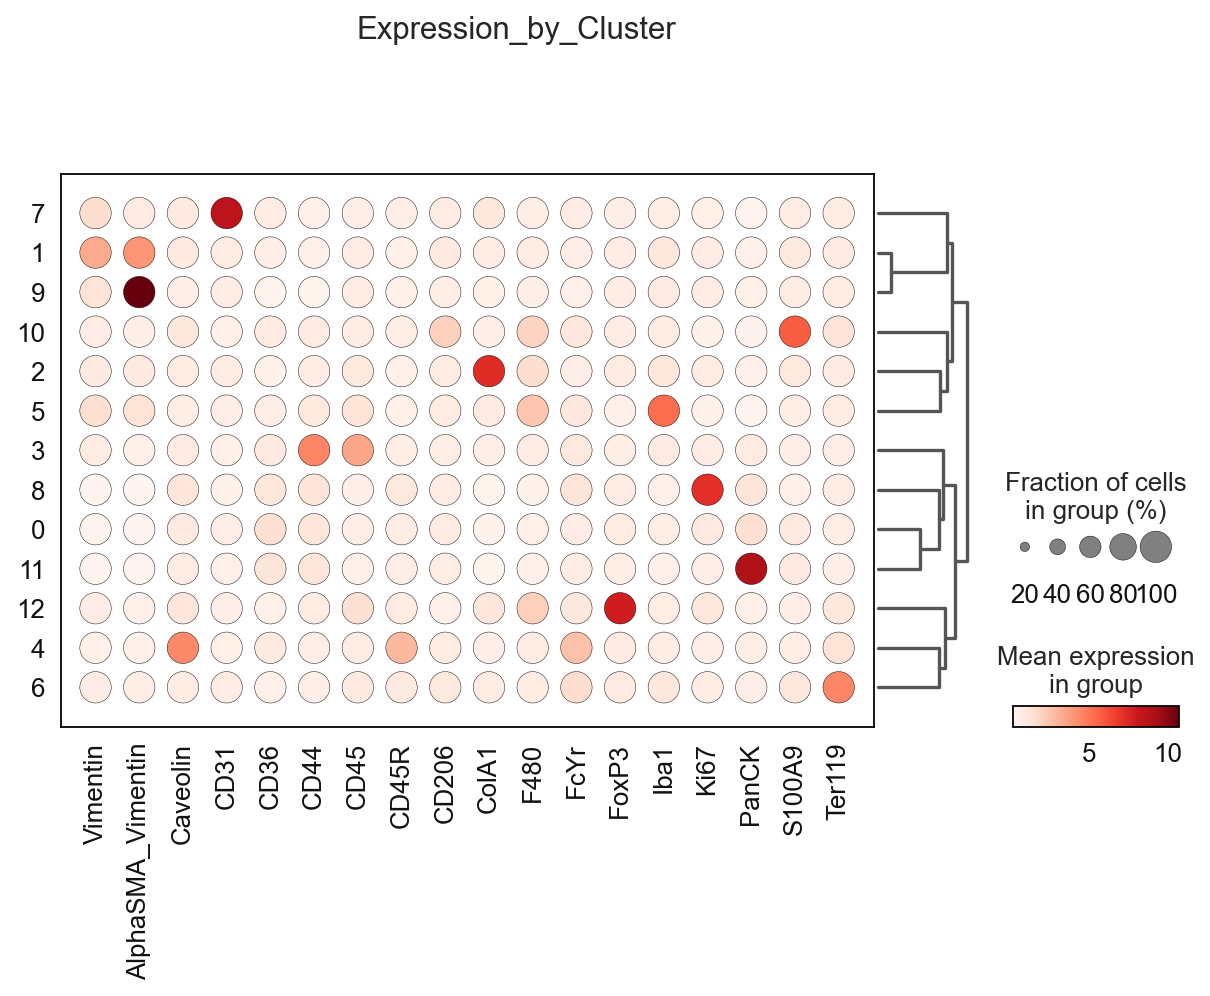

In [37]:
sc.pl.umap(adata, color = ['leiden_0.25'], wspace=0.9, title = 'UMAP') #if CD45 looks like it's not plotting, it's just that expression is incredibly low lol"""
sc.pl.dotplot(adata, 
              marker_list,
              'leiden_0.25',
              dendrogram=True,
              title='Expression_by_Cluster')